# Genomic ResNet (Residual Network)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# 1. Define where your zip file is in Drive
# Hint: If you just uploaded it to the main folder, it's likely here:
zip_path = '/content/drive/MyDrive/breast-cancer-gene-expression-cumida.zip'

# 2. Unzip into a local folder
!unzip "$zip_path" -d "/content/cumida_data"

# 3. Check the file name inside
print("Files found:", os.listdir("/content/cumida_data"))

Archive:  /content/drive/MyDrive/breast-cancer-gene-expression-cumida.zip
  inflating: /content/cumida_data/Breast_GSE45827.csv  
Files found: ['Breast_GSE45827.csv']


In [ ]:
import pandas as pd
import glob

# Find the CSV automatically (so exact filename doesn't matter)
csv_files = glob.glob('/content/cumida_data/*.csv')

if csv_files:
    file_path = csv_files[0]
    print(f"Loading: {file_path}")
    df = pd.read_csv(file_path)

    # Quick sanity check
    print(f"Data Shape: {df.shape}") # Should be approx (151, 54678)
    print("Classes:", df['type'].unique())
else:
    print("No CSV found! Check your zip file.")

Loading: /content/cumida_data/Breast_GSE45827.csv
Data Shape: (151, 54677)
Classes: ['basal' 'HER' 'cell_line' 'normal' 'luminal_A' 'luminal_B']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Load Data (assuming you unzipped it as discussed)
# Replace with your actual path if different
df = pd.read_csv('/content/cumida_data/Breast_GSE45827.csv')

# 2. Separate Target & Features
# 'type' is usually the target in CuMiDa, 'samples' is metadata
X = df.drop(['samples', 'type'], axis=1)
y = df['type']

# 3. Label Encoding (Target)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Classes found: {le.classes_}")

# 4. Train/Test Split (Stratified is crucial for small data!)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# --- BRANCH A: For Traditional & Transformer (Numerical) ---

# Step A1: Feature Selection (Reduce 54k -> 2k genes)
# We only fit this on TRAIN data to avoid data leakage
selector = SelectKBest(score_func=f_classif, k=10000)
selector.fit(X_train_raw, y_train)

# Get the names of the top genes (We need these for the LLM later!)
top_gene_names = X.columns[selector.get_support()]

# Transform the data
X_train_reduced = selector.transform(X_train_raw)
X_test_reduced = selector.transform(X_test_raw)

# Step A2: Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

print(f"Original Shape: {X_train_raw.shape}")
print(f"Processed Shape: {X_train_scaled.shape}")

# --- BRANCH B: For LLM (Text Serialization) ---

def serialize_row(row_values, feature_names):
    """Convert a row of gene values into a text description."""
    text_parts = []
    # We zip the gene names with their values
    for name, val in zip(feature_names, row_values):
        # We can simplify: is it positive (up-regulated) or negative?
        status = "high" if val > 0 else "low"
        text_parts.append(f"{name} is {status}")

    # Join first 50 genes to keep text length manageable for BERT
    return "Breast cancer profile: " + ", ".join(text_parts[:50]) + "."

# Apply to Train data
# Note: We use the REDUCED data so we only serialize important genes
X_train_text = [serialize_row(row, top_gene_names) for row in X_train_reduced]
X_test_text = [serialize_row(row, top_gene_names) for row in X_test_reduced]

print(f"LLM Example Input: {X_train_text[0][:100]}...")

Classes found: ['HER' 'basal' 'cell_line' 'luminal_A' 'luminal_B' 'normal']
Original Shape: (120, 54675)
Processed Shape: (120, 10000)
LLM Example Input: Breast cancer profile: 1053_at is high, 117_at is high, 1487_at is high, 1552263_at is high, 1552264...


🚀 Custom ResNet initialized on cuda for 10000 features.
CustomGenomicResNet(
  (input_layer): Sequential(
    (0): Linear(in_features=10000, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (res_block1): ResidualBlock(
    (block): Sequential(
      (0): Linear(in_features=512, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
    )
  )
  (res_block2): ResidualBlock(
    (block): Sequential(
      (0): Linear(in_features=512, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
    )
  )
  (output_head): Sequential(
    (0): Linear(in_features=512, out_features=6, bias=True)
  )
)

Starting Training...
Epoch 10/50 | Loss: 0.0275 | Train Acc: 0

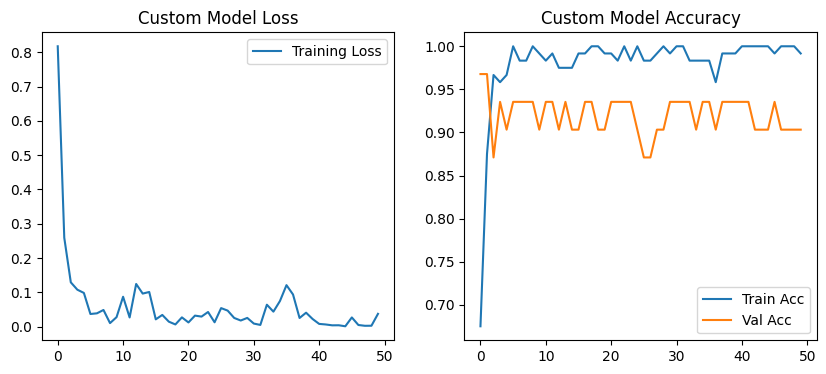

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# --- 1. DEFINE THE DATASET (Standard PyTorch) ---
class GenomicDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create DataLoaders
# We use the SCALED numerical data (10k features)
train_dataset = GenomicDataset(X_train_scaled, y_train)
test_dataset = GenomicDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# --- 2. DEFINE CUSTOM ARCHITECTURE (Residual MLP) ---
class ResidualBlock(nn.Module):
    def __init__(self, hidden_dim, dropout_rate=0.3):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )

    def forward(self, x):
        # The "Skip Connection": Output = Input + Processed(Input)
        return x + self.block(x)

class CustomGenomicResNet(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=512):
        super(CustomGenomicResNet, self).__init__()

        # 1. Projection Layer (Compress 10k -> 512)
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )

        # 2. Residual Blocks (Deep Learning part)
        # These layers learn complex non-linear gene interactions
        self.res_block1 = ResidualBlock(hidden_dim)
        self.res_block2 = ResidualBlock(hidden_dim)

        # 3. Output Layer
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        logits = self.output_head(x)
        return logits

# --- 3. INITIALIZE MODEL ---
INPUT_DIM = X_train_scaled.shape[1] # 10,000
NUM_CLASSES = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_custom = CustomGenomicResNet(INPUT_DIM, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_custom.parameters(), lr=1e-3, weight_decay=1e-2)

print(f"🚀 Custom ResNet initialized on {device} for {INPUT_DIM} features.")
print(model_custom)

# --- 4. TRAINING LOOP ---
EPOCHS = 50
train_accs, val_accs = [], []
losses = []

print("\nStarting Training...")
for epoch in range(EPOCHS):
    model_custom.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward
        optimizer.zero_grad()
        outputs = model_custom(inputs)
        loss = criterion(outputs, labels)

        # Backward
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # Validation
    model_custom.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_custom(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    # Logs
    epoch_acc = correct_train / total_train
    val_acc = correct_test / total_test
    train_accs.append(epoch_acc)
    val_accs.append(val_acc)
    losses.append(running_loss / len(train_loader))

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {losses[-1]:.4f} | Train Acc: {epoch_acc:.4f} | Val Acc: {val_acc:.4f}")

# --- 5. FINAL EVALUATION ---
print(f"\n✅ Custom Model Final Accuracy: {val_accs[-1]:.4f}")

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(losses, label='Training Loss')
plt.title('Custom Model Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Custom Model Accuracy')
plt.legend()
plt.show()

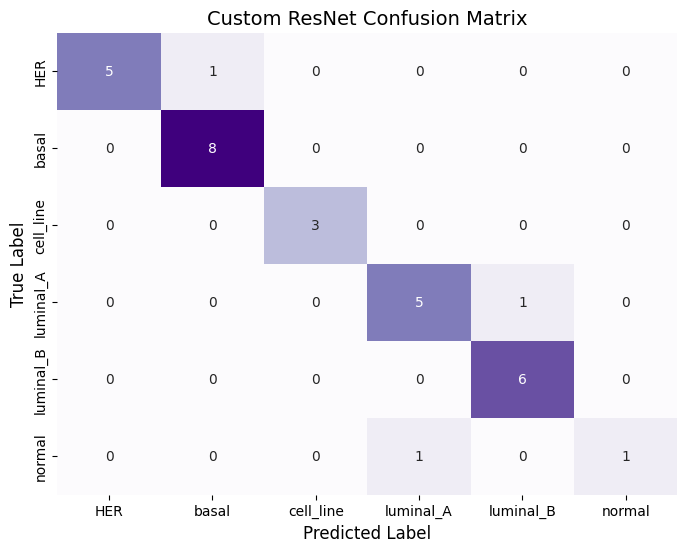

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Get Predictions from the Custom ResNet
model_custom.eval()
y_pred_resnet = []
y_true_resnet = []

# Loop through test loader to gather all predictions
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_custom(inputs)
        _, predicted = torch.max(outputs, 1)

        y_pred_resnet.extend(predicted.cpu().numpy())
        y_true_resnet.extend(labels.cpu().numpy())

# 2. Compute Matrix
cm = confusion_matrix(y_true_resnet, y_pred_resnet)

# 3. Plot (Using 'Purples' to distinguish Custom Models)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Custom ResNet Confusion Matrix', fontsize=14)
plt.show()

✅ Custom Model Precision & Recall Report:

              precision    recall  f1-score   support

         HER       1.00      0.83      0.91         6
       basal       0.89      1.00      0.94         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       0.83      0.83      0.83         6
   luminal_B       0.86      1.00      0.92         6
      normal       1.00      0.50      0.67         2

    accuracy                           0.90        31
   macro avg       0.93      0.86      0.88        31
weighted avg       0.91      0.90      0.90        31



/tmp/ipython-input-173774413.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


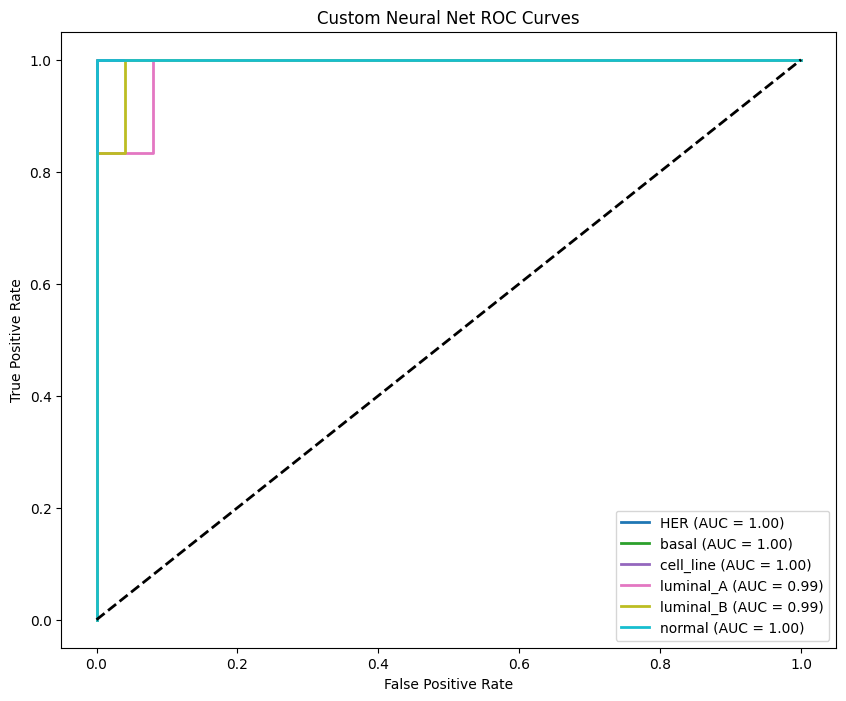

In [ ]:
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

# Select the model you want to plot (model_custom OR model)
active_model = model_custom  # Change to 'model' for Autoencoder
active_model.eval()

# --- 1. Loop to Gather Probabilities ---
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = active_model(inputs)
        probs = F.softmax(outputs, dim=1) # Softmax for probabilities
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

y_probs = np.concatenate(all_probs)
y_true = np.concatenate(all_labels)

# Binarize
y_test_bin = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_test_bin.shape[1]
y_pred_class = np.argmax(y_probs, axis=1)

# --- 2. Print Precision/Recall Values ---
print("✅ Custom Model Precision & Recall Report:\n")
# Note: You might need to manually list target_names if 'le' isn't available
print(classification_report(y_true, y_pred_class, target_names=le.classes_))

# --- 3. Plot ROC Curve ---
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors(i), lw=2,
             label=f'{le.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Custom Neural Net ROC Curves')
plt.legend(loc="lower right")
plt.show()